# เวิร์กชอป: การแบ่งส่วนภาพช้าง (Elephant Segmentation) ด้วยการประมวลผลภาพเชิงมอร์โฟโลยี

**รายวิชา:** Digital Image Processing — Lecture 10 (Morphological Processing)
**ชุดข้อมูล (Dataset):** `raw_data/` — ภาพถ่ายช้างจำนวน 56 ภาพ (ส่งออกจาก Roboflow)

โน้ตบุ๊กนี้เป็นการทำงานตามเวิร์กชอปกลุ่มที่ระบุไว้ท้าย
*Lecture 10 — Morphological Processing*:

1. เลือกงานแบ่งส่วนภาพ (segmentation task): แยก **วัตถุ** (ช้าง) ออกจาก
   **พื้นหลัง**
2. จัดหาชุดข้อมูลอย่างน้อย 50 ภาพ พร้อม ground truth (ถ้าไม่มีให้สร้างขึ้นเอง)
3. ออกแบบอัลกอริทึมแบบดั้งเดิม (classical) เพื่อแยกวัตถุ (**คลาสบวก**)
   ออกจากพื้นหลัง (**คลาสลบ**)
4. ใช้ **ตัวดำเนินการเชิงมอร์โฟโลยี (morphological operators)** เพื่อปรับปรุงผลการแบ่งส่วนภาพ
5. ประเมินผลด้วย **Confusion Matrix** และ **ROC Curve** พร้อมอภิปรายผล
6. นำเสนอผลการศึกษา

---
### หมายเหตุเกี่ยวกับ ground truth

โฟลเดอร์ `raw_data/` มีเพียงภาพถ่ายดิบเท่านั้น — ไม่มีการให้ mask/label มาด้วย
การติดป้ายกำกับ (label) ทีละพิกเซลด้วยมือสำหรับภาพ 56 ภาพนั้นไม่สะดวกในทางปฏิบัติ
ดังนั้น ตามที่โจทย์อนุญาตไว้อย่างชัดเจน ("ถ้าไม่มี ให้สร้างขึ้นมาเอง")
เราจึงสร้าง mask อ้างอิงขึ้นเองโดยอัตโนมัติ (ดูไฟล์ `01_generate_ground_truth.py`):

- **วิธีหลัก — ตัวตรวจจับเฉพาะคลาส (class-specific detector).** เราใช้ **YOLOv8x-seg**
  ซึ่งเป็นโมเดล instance segmentation ที่ผ่านการเทรนล่วงหน้าบน COCO และเก็บไว้เฉพาะ
  instance mask ที่โมเดลทำนายว่าเป็นคลาส **"elephant"** เท่านั้น (รวม mask
  เข้าด้วยกันหากภาพหนึ่งมีช้างมากกว่าหนึ่งตัว) วิธีนี้จะไม่รวมคน สัตว์อื่น
  และสิ่งรบกวนในพื้นหลัง ซึ่งต่างจากโมเดล saliency แบบทั่วไปที่ไม่เจาะจงคลาส
- **วิธีสำรอง (3/56 ภาพ).** ภาพบางภาพที่มีมุมกล้อง/แสงผิดปกติทำให้ตัวตรวจจับ
  หาช้างไม่เจอเลย (ตรวจพบ 0 ตัว) สำหรับภาพเหล่านี้เท่านั้น เราจะใช้ mask
  saliency แบบทั่วไปแทน (U2-Net ผ่านไลบรารี `rembg`) — สคริปต์จะพิมพ์รายชื่อ
  ภาพที่ใช้วิธีสำรองนี้ออกมาเพื่อให้ตรวจสอบได้

ข้อจำกัดนี้จะถูกเปิดเผยและอภิปรายไว้ท้ายโน้ตบุ๊ก


In [1]:
import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# ตั้งค่าฟอนต์ให้รองรับภาษาไทยในกราฟ matplotlib
plt.rcParams["font.family"] = ["Loma", "Tahoma", "Leelawadee UI", "TH Sarabun New", "Noto Sans Thai", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

RAW_DIR = "raw_data"
GT_DIR  = "gt_masks"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["figure.facecolor"] = "white"
np.random.seed(0)


## ขั้นตอนที่ 1 — ชุดข้อมูลและ ground truth

โหลดภาพต้นฉบับและ mask ของ ground truth ที่ตรงกัน (สร้างไว้แล้วโดย
`01_generate_ground_truth.py` — mask เฉพาะช้างจาก YOLOv8x-seg
พร้อมวิธีสำรองแบบ saliency ทั่วไปสำหรับภาพบางส่วน ดูหมายเหตุด้านบน)
mask หนึ่งไฟล์ PNG ต่อภาพ JPG หนึ่งภาพ โดยสีขาว = ช้าง/วัตถุ (foreground),
สีดำ = พื้นหลัง (background)


In [ ]:
files = sorted(f for f in os.listdir(RAW_DIR) if f.lower().endswith(".jpg"))
print(f"จำนวนภาพในชุดข้อมูล: {len(files)}")

imgs, gts = {}, {}
for f in files:
    img = cv2.imread(os.path.join(RAW_DIR, f))
    gt_path = os.path.join(GT_DIR, os.path.splitext(f)[0] + "_mask.png")
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    imgs[f] = img
    gts[f] = (gt > 127).astype(np.uint8)

mean_fg_frac = np.mean([gts[f].mean() for f in files])
print(f"สัดส่วนพิกเซล foreground (ช้าง) เฉลี่ยใน ground truth: {mean_fg_frac:.1%}")


จำนวนภาพในชุดข้อมูล: 56


สัดส่วนพิกเซล foreground (ช้าง) เฉลี่ยใน ground truth: 36.0%


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


...

findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


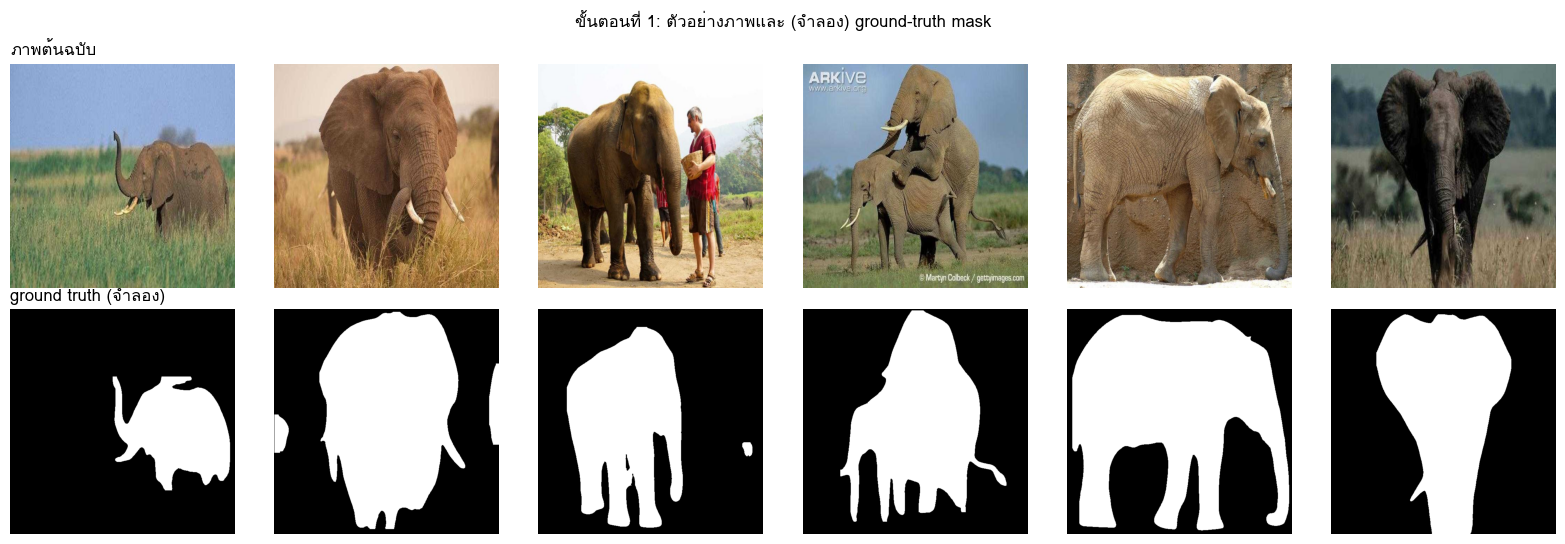

In [3]:
# ตรวจสอบความถูกต้องเบื้องต้น: แสดงตัวอย่างภาพบางส่วนพร้อม ground-truth mask
sample = files[:6]
fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
for i, f in enumerate(sample):
    axes[0, i].imshow(cv2.cvtColor(imgs[f], cv2.COLOR_BGR2RGB)); axes[0, i].axis("off")
    axes[1, i].imshow(gts[f], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("ภาพต้นฉบับ", loc="left"); axes[1, 0].set_title("ground truth (จำลอง)", loc="left")
plt.suptitle("ขั้นตอนที่ 1: ตัวอย่างภาพและ (จำลอง) ground-truth mask")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_dataset_sample.png", dpi=130)
plt.show()


## ขั้นตอนที่ 2 — อัลกอริทึมแบ่งส่วนภาพแบบดั้งเดิม (classical)

**แนวคิด:** แถบขอบบาง ๆ ทั้งสี่ด้านของภาพแต่ละภาพมักจะเป็นพื้นหลังเสมอ
(หญ้า / ท้องฟ้า / ดิน / รั้ว ฯลฯ) สำหรับแต่ละภาพเราจะ:

1. สุ่มตัวอย่างพิกเซลบริเวณขอบภาพ แล้วคำนวณค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน
   ในปริภูมิสี **CIE-Lab**
2. คำนวณระยะห่างสี (colour distance) แบบ Euclidean ที่ถูก z-score
   ของทุกพิกเซลเทียบกับค่าสถิติสีพื้นหลังนั้น
3. กำหนดค่าขีดแบ่ง (threshold) `t` บนแผนที่ระยะห่าง → ได้ mask แบบไบนารี
   (`1` = ห่างจากสีพื้นหลังมาก ⇒ พิกเซลที่คาดว่าเป็นช้าง)

นี่คือกฎแบบ **ดั้งเดิม (ไม่ใช้ deep learning)** ง่าย ๆ ซึ่งตรงกับที่บทเรียนได้
เตือนไว้ว่าจะเกิดสัญญาณรบกวนแบบ "salt-and-pepper" — นี่จึงเป็นเหตุผลที่ต้อง
ทำความสะอาดด้วยมอร์โฟโลยี (ขั้นตอนที่ 4) ในภายหลัง


In [4]:
def bg_distance_map(img_bgr, border_frac=0.04):
    '''ระยะห่างสี Lab แบบ z-score ของทุกพิกเซล เทียบกับตัวอย่างพื้นหลังที่ขอบภาพ'''
    h, w = img_bgr.shape[:2]
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    bh, bw = max(2, int(h * border_frac)), max(2, int(w * border_frac))
    border_px = np.concatenate([
        lab[:bh, :, :].reshape(-1, 3), lab[-bh:, :, :].reshape(-1, 3),
        lab[:, :bw, :].reshape(-1, 3), lab[:, -bw:, :].reshape(-1, 3),
    ], axis=0)
    mean = border_px.mean(axis=0)
    std = border_px.std(axis=0) + 1e-3
    return np.sqrt((((lab - mean) / std) ** 2).sum(axis=2))


def segment_raw(img_bgr, threshold):
    '''แบ่งส่วนภาพ foreground/background แบบดั้งเดิมด้วย threshold -> mask {0,1}'''
    return (bg_distance_map(img_bgr) > threshold).astype(np.uint8)


# คำนวณแผนที่ระยะห่าง (distance map) ของทุกภาพไว้ล่วงหน้าเพียงครั้งเดียว (นำไปใช้ซ้ำตลอดการหา ROC)
dmaps = {f: bg_distance_map(imgs[f]) for f in files}
print("คำนวณแผนที่ระยะห่างเสร็จแล้วสำหรับ", len(dmaps), "ภาพ")


คำนวณแผนที่ระยะห่างเสร็จแล้วสำหรับ 56 ภาพ


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


...

findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


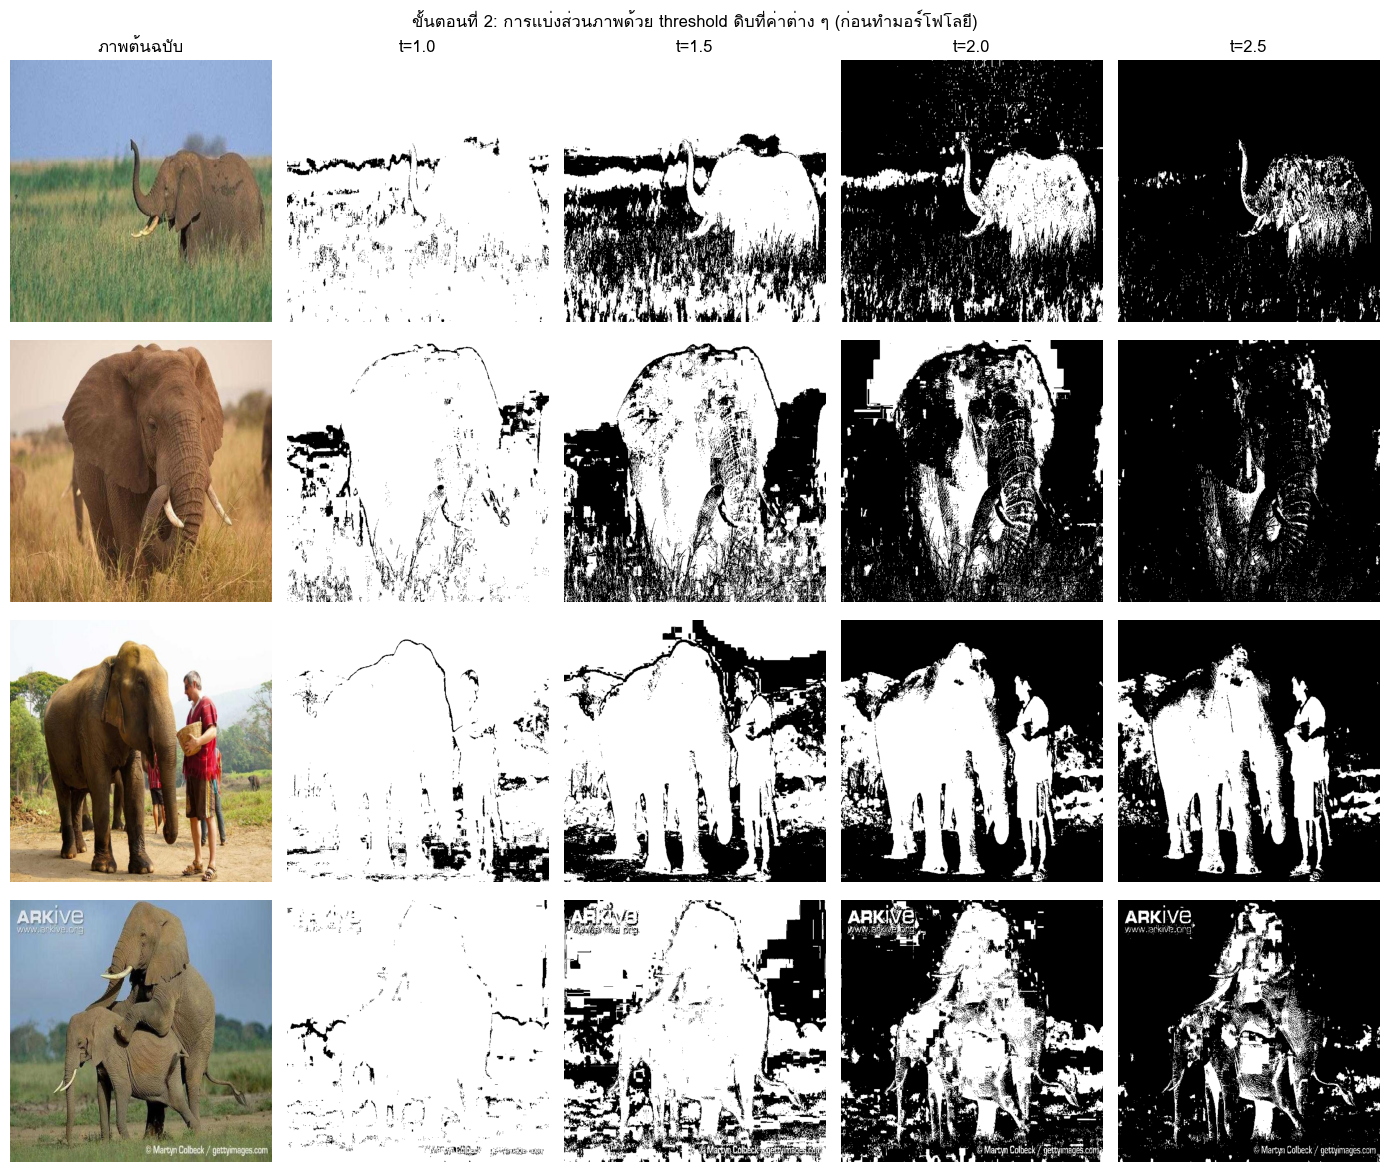

In [5]:
# แสดงผลกระทบของค่า threshold ต่อภาพตัวอย่างบางส่วน
sample = files[:4]
test_thresholds = [1.0, 1.5, 2.0, 2.5]
fig, axes = plt.subplots(len(sample), len(test_thresholds) + 1, figsize=(14, 3 * len(sample)))
for r, f in enumerate(sample):
    axes[r, 0].imshow(cv2.cvtColor(imgs[f], cv2.COLOR_BGR2RGB)); axes[r, 0].axis("off")
    for c, t in enumerate(test_thresholds):
        mask = (dmaps[f] > t).astype(np.uint8) * 255
        axes[r, c + 1].imshow(mask, cmap="gray"); axes[r, c + 1].axis("off")
        if r == 0:
            axes[r, c + 1].set_title(f"t={t}")
axes[0, 0].set_title("ภาพต้นฉบับ")
plt.suptitle("ขั้นตอนที่ 2: การแบ่งส่วนภาพด้วย threshold ดิบที่ค่าต่าง ๆ (ก่อนทำมอร์โฟโลยี)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_threshold_sweep_examples.png", dpi=130)
plt.show()


## ขั้นตอนที่ 3 — Confusion matrix และ ROC curve (อัลกอริทึมดิบ ก่อนทำมอร์โฟโลยี)

เราจะไล่ค่า threshold `t` และในแต่ละค่า จะรวม **TP / FP / TN / FN**
จาก *ทุกพิกเซลของทุกภาพ* ในชุดข้อมูล (ประเมินผลระดับพิกเซล)
การพล็อต **True Positive Rate เทียบกับ False Positive Rate** ในทุกค่า threshold
จะได้ ROC curve และเราจะเลือกค่า threshold ที่ใช้งานจริงด้วย
**สถิติ Youden's J** (`J = TPR − FPR` ซึ่งมีค่าสูงสุดที่จุดใกล้มุมซ้ายบนของ ROC curve มากที่สุด)


In [6]:
def confusion_counts(pred01, gt01):
    pred = pred01.astype(bool); gt = gt01.astype(bool)
    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    return tp, fp, tn, fn

def metrics_from_counts(tp, fp, tn, fn):
    p, n = tp + fn, tn + fp
    acc = (tp + tn) / (p + n) if (p + n) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / p if p else 0.0
    fpr = fp / n if n else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return dict(accuracy=acc, precision=precision, recall=recall, tpr=recall,
                fpr=fpr, f1=f1, tp=tp, fp=fp, tn=tn, fn=fn)

thresholds = np.arange(0.2, 4.61, 0.1)
roc_rows = []
for t in thresholds:
    TP=FP=TN=FN=0
    for f in files:
        tp, fp, tn, fn = confusion_counts((dmaps[f] > t).astype(np.uint8), gts[f])
        TP+=tp; FP+=fp; TN+=tn; FN+=fn
    m = metrics_from_counts(TP, FP, TN, FN)
    roc_rows.append((t, m["fpr"], m["tpr"], m["f1"], m["accuracy"]))
roc_rows = np.array(roc_rows)

J = roc_rows[:, 2] - roc_rows[:, 1]
best_idx = int(np.argmax(J))
BEST_T = float(roc_rows[best_idx, 0])

order = np.argsort(roc_rows[:, 1])
trapz_fn = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
auc = float(trapz_fn(roc_rows[order, 2], roc_rows[order, 1]))

print(f"ค่า threshold ที่เลือกใช้งาน (Youden's J สูงสุด): t = {BEST_T:.2f}")
print(f"  -> TPR = {roc_rows[best_idx,2]:.3f}, FPR = {roc_rows[best_idx,1]:.3f}, F1 = {roc_rows[best_idx,3]:.3f}")
print(f"ค่า ROC AUC โดยประมาณ = {auc:.3f}")


ค่า threshold ที่เลือกใช้งาน (Youden's J สูงสุด): t = 2.10
  -> TPR = 0.572, FPR = 0.184, F1 = 0.603
ค่า ROC AUC โดยประมาณ = 0.733


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


...

findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


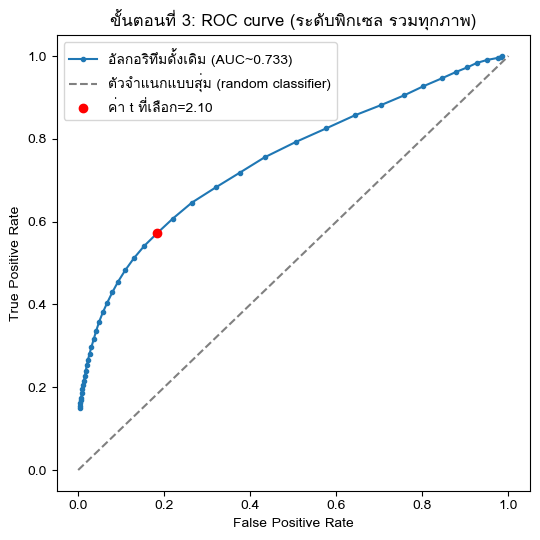

In [7]:
plt.figure(figsize=(5.5, 5.5))
plt.plot(roc_rows[:, 1], roc_rows[:, 2], "-o", ms=3, label=f"อัลกอริทึมดั้งเดิม (AUC~{auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="ตัวจำแนกแบบสุ่ม (random classifier)")
plt.scatter([roc_rows[best_idx, 1]], [roc_rows[best_idx, 2]], color="red", zorder=5,
            label=f"ค่า t ที่เลือก={BEST_T:.2f}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ขั้นตอนที่ 3: ROC curve (ระดับพิกเซล รวมทุกภาพ)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_roc_curve.png", dpi=130)
plt.show()


## ขั้นตอนที่ 4 — การปรับปรุงด้วยมอร์โฟโลยี (Morphological improvement)

ที่ค่า threshold `t` ที่เลือกไว้ mask ดิบยังคงมีสัญญาณรบกวน (จุดเล็ก ๆ, รู, หรือ
บริเวณเล็ก ๆ ที่หลุดออกมา) เราจะทำความสะอาดด้วยตัวดำเนินการจาก Lecture 10:

- **Opening** (`erosion → dilation`) — ลบจุดสัญญาณรบกวนเล็ก ๆ ที่มีขนาด
  เล็กกว่า structuring element
- **Closing** (`dilation → erosion`) — เติมช่องว่าง/รอยขาดเล็ก ๆ ให้เต็ม
- **Region filling** (การเติมรู) — เติมรูพื้นหลังที่ถูกล้อมรอบทั้งหมดให้เต็ม
- **การลบก้อนเล็ก (small-blob removal)** (การกรองด้วย connected-component) —
  ตัดก้อนสัญญาณรบกวนที่เหลือซึ่งมีขนาดเล็กกว่า 1% ของพื้นที่ภาพทิ้งไป


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


...

findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


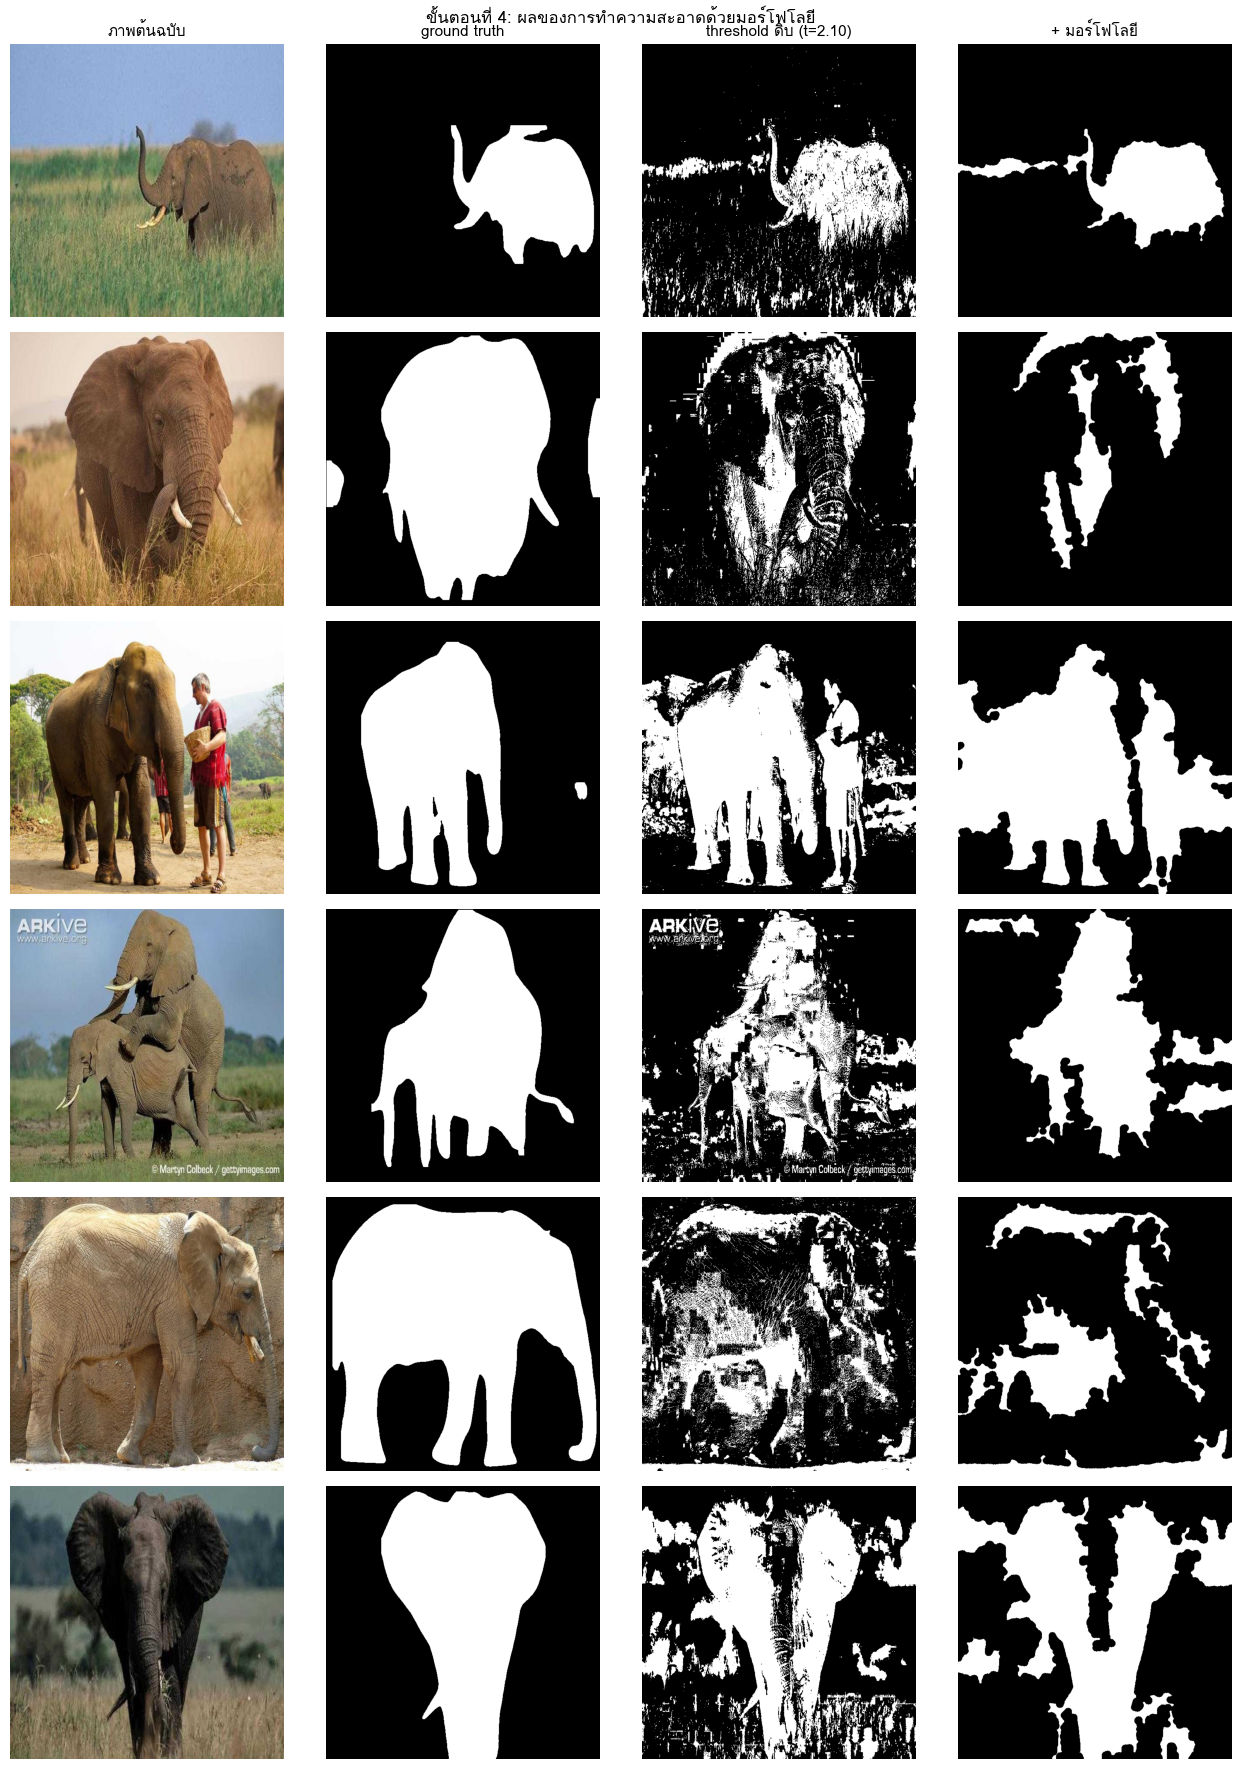

In [8]:
def apply_morphology(mask01, k_open=5, k_close=17, min_area_frac=0.01):
    m = mask01.astype(np.uint8)
    se_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_open, k_open))
    se_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_close, k_close))

    opened = cv2.morphologyEx(m, cv2.MORPH_OPEN, se_open)          # I o H (opening)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, se_close)   # I . H (closing)
    filled = ndi.binary_fill_holes(closed).astype(np.uint8)        # เติมรู (region filling)

    n, lbl, stats, _ = cv2.connectedComponentsWithStats(filled, connectivity=8)
    total = m.shape[0] * m.shape[1]
    out = np.zeros_like(filled)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area_frac * total:
            out[lbl == i] = 1
    return out

# เปรียบเทียบภาพก่อน/หลังการทำมอร์โฟโลยี
sample = files[:6]
fig, axes = plt.subplots(len(sample), 4, figsize=(13, 3 * len(sample)))
for r, f in enumerate(sample):
    raw = (dmaps[f] > BEST_T).astype(np.uint8)
    clean = apply_morphology(raw)
    axes[r, 0].imshow(cv2.cvtColor(imgs[f], cv2.COLOR_BGR2RGB)); axes[r, 0].axis("off")
    axes[r, 1].imshow(gts[f], cmap="gray"); axes[r, 1].axis("off")
    axes[r, 2].imshow(raw * 255, cmap="gray"); axes[r, 2].axis("off")
    axes[r, 3].imshow(clean * 255, cmap="gray"); axes[r, 3].axis("off")
for i, t in enumerate(["ภาพต้นฉบับ", "ground truth", f"threshold ดิบ (t={BEST_T:.2f})", "+ มอร์โฟโลยี"]):
    axes[0, i].set_title(t, fontsize=11)
plt.suptitle("ขั้นตอนที่ 4: ผลของการทำความสะอาดด้วยมอร์โฟโลยี")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_morphology_before_after.png", dpi=130)
plt.show()


## ขั้นตอนที่ 5 — การประเมินผลสุดท้าย: confusion matrix ก่อนและหลังทำมอร์โฟโลยี

เราจะรวม confusion matrix จากทั้งชุดข้อมูล **ที่ threshold ที่เลือกไว้**
ทั้งของ mask ดิบและ mask ที่ผ่านการทำความสะอาดด้วยมอร์โฟโลยีแล้ว
จากนั้นเปรียบเทียบค่า Accuracy / Precision / Recall / F1


In [9]:
TP=FP=TN=FN=0
TPm=FPm=TNm=FNm=0
for f in files:
    raw = (dmaps[f] > BEST_T).astype(np.uint8)
    clean = apply_morphology(raw)
    tp, fp, tn, fn = confusion_counts(raw, gts[f]); TP+=tp; FP+=fp; TN+=tn; FN+=fn
    tpc, fpc, tnc, fnc = confusion_counts(clean, gts[f]); TPm+=tpc; FPm+=fpc; TNm+=tnc; FNm+=fnc

m_raw = metrics_from_counts(TP, FP, TN, FN)
m_clean = metrics_from_counts(TPm, FPm, TNm, FNm)

import pandas as pd
table = pd.DataFrame({
    "Threshold ดิบ": {k: m_raw[k] for k in ["accuracy","precision","recall","fpr","f1"]},
    "หลังทำมอร์โฟโลยี": {k: m_clean[k] for k in ["accuracy","precision","recall","fpr","f1"]},
})
table.index = ["ความแม่นยำโดยรวม (Accuracy)","ความแม่นยำเชิงบวก (Precision)","ความไว (Recall/TPR)","Fall-out (FPR)","F1-score"]
display(table.round(4))

with open(f"{OUT_DIR}/metrics_summary.json", "w") as fp:
    json.dump({"best_threshold": BEST_T, "auc": auc, "raw": m_raw, "after_morphology": m_clean}, fp, indent=2)


,Threshold ดิบ,หลังทำมอร์โฟโลยี
ความแม่นยำโดยรวม (Accuracy),0.7284,0.7421
ความแม่นยำเชิงบวก (Precision),0.6369,0.6637
ความไว (Recall/TPR),0.5722,0.5761
Fall-out (FPR),0.1837,0.1644
F1-score,0.6028,0.6168


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


...

findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


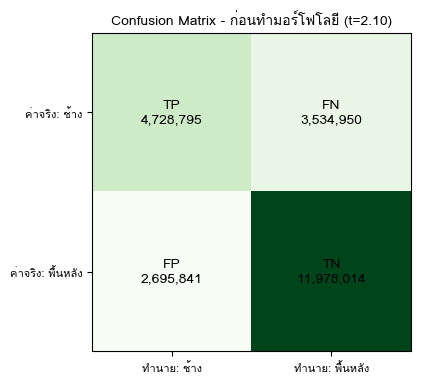

findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


...

findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


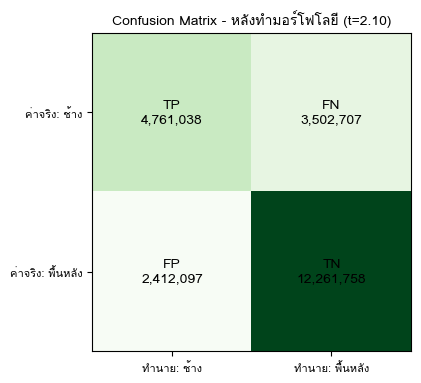

In [10]:
def plot_cm(m, title, path):
    cm = np.array([[m['tp'], m['fn']], [m['fp'], m['tn']]])
    fig, ax = plt.subplots(figsize=(4.3, 4.3))
    ax.imshow(cm, cmap='Greens')
    labels = [["TP", "FN"], ["FP", "TN"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}", ha='center', va='center', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["ทำนาย: ช้าง", "ทำนาย: พื้นหลัง"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["ค่าจริง: ช้าง", "ค่าจริง: พื้นหลัง"], fontsize=8)
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.savefig(path, dpi=130)

plot_cm(m_raw, f"Confusion Matrix - ก่อนทำมอร์โฟโลยี (t={BEST_T:.2f})", f"{OUT_DIR}/05_cm_raw.png")
plt.show()
plot_cm(m_clean, f"Confusion Matrix - หลังทำมอร์โฟโลยี (t={BEST_T:.2f})", f"{OUT_DIR}/05_cm_morph.png")
plt.show()


/tmp/ipykernel_1764/524774568.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([f1_raw_list, f1_clean_list], labels=["Threshold ดิบ", "หลังทำมอร์โฟโลยี"])
findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


...

findfont: Font family 'Noto Sans Thai' not found.


findfont: Font family 'Tahoma' not found.


findfont: Font family 'Leelawadee UI' not found.


findfont: Font family 'TH Sarabun New' not found.


findfont: Font family 'Noto Sans Thai' not found.


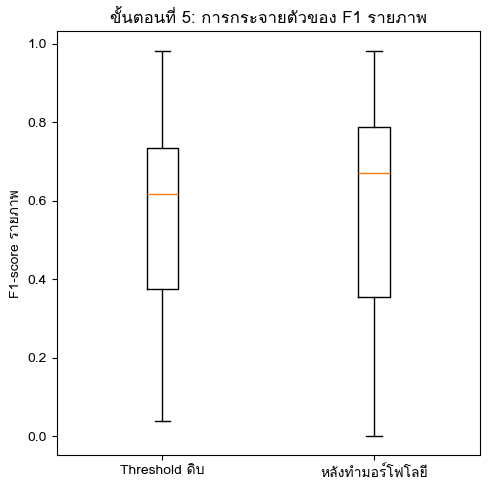

ค่าเฉลี่ย F1 รายภาพ  ดิบ=0.561  หลังทำมอร์โฟโลยี=0.575
จำนวนภาพที่ดีขึ้นจากมอร์โฟโลยี: 30/56


In [11]:
# การกระจายตัวของ F1 รายภาพ เปรียบเทียบก่อน/หลังทำมอร์โฟโลยี (เปรียบเทียบแบบจับคู่)
f1_raw_list, f1_clean_list = [], []
for f in files:
    raw = (dmaps[f] > BEST_T).astype(np.uint8)
    clean = apply_morphology(raw)
    f1_raw_list.append(metrics_from_counts(*confusion_counts(raw, gts[f]))["f1"])
    f1_clean_list.append(metrics_from_counts(*confusion_counts(clean, gts[f]))["f1"])

plt.figure(figsize=(5, 5))
plt.boxplot([f1_raw_list, f1_clean_list], labels=["Threshold ดิบ", "หลังทำมอร์โฟโลยี"])
plt.ylabel("F1-score รายภาพ")
plt.title("ขั้นตอนที่ 5: การกระจายตัวของ F1 รายภาพ")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_f1_boxplot.png", dpi=130)
plt.show()
print(f"ค่าเฉลี่ย F1 รายภาพ  ดิบ={np.mean(f1_raw_list):.3f}  หลังทำมอร์โฟโลยี={np.mean(f1_clean_list):.3f}")
print(f"จำนวนภาพที่ดีขึ้นจากมอร์โฟโลยี: {sum(c>=r for c,r in zip(f1_clean_list,f1_raw_list))}/{len(files)}")


## อภิปรายผล

**เรื่อง ROC / การเลือก threshold** ROC curve ระดับพิกเซลมีค่า AUC โดยประมาณอยู่ที่
~0.733 — ดีกว่าตัวจำแนกแบบสุ่มอย่างชัดเจน (AUC 0.5) แต่ยังห่างไกลจากตัวจำแนกที่สมบูรณ์แบบ
(AUC 1.0) ซึ่งเป็นผลที่คาดไว้อยู่แล้ว เนื่องจากอัลกอริทึมนี้เป็นกฎแบบ *ง่าย ใช้สีอย่างเดียว
และเป็นแบบ global* ในขณะที่ภาพช้างมีพื้นหลังหลากหลายมาก (หญ้าเขียว หญ้าแห้ง ดิน ท้องฟ้า
น้ำ) เราเลือก threshold ที่ใช้งานจริงโดยใช้ค่าที่ทำให้สถิติ Youden's J สูงสุด
กล่าวคือจุดบน ROC curve ที่ใกล้มุมซ้ายบนที่สุด ("จุดสมดุลที่ดีที่สุด" ระหว่าง sensitivity
และ specificity) แทนที่จะเลือกจุดที่ทำให้ accuracy สูงสุดเพียงอย่างเดียว
(ซึ่งจะถูกครอบงำโดยคลาสพื้นหลังที่มักมีขนาดใหญ่กว่า)

**ผลของมอร์โฟโลยี** เมื่อเปรียบเทียบ confusion matrix ก่อน/หลังการประมวลผลด้วยมอร์โฟโลยี
(accuracy 72.8% → 74.2%, precision 63.7% → 66.4%, FPR 18.4% → 16.4%,
F1 0.603 → 0.617):
- **False positive ลดลง** อย่างเห็นได้ชัด — การทำ opening ช่วยลบพื้นที่พื้นหลังเล็ก ๆ
  ที่แยกตัวออกมาซึ่งถูกจำแนกผิดเนื่องจากสัญญาณรบกวนของสีในบริเวณนั้น (เช่น หญ้าที่โดนแดด
  หรือเงา)
- **Precision และ accuracy โดยรวมดีขึ้น** เนื่องจากการทำ closing ร่วมกับการเติมรู
  และการลบก้อนเล็ก ช่วยเปลี่ยน mask ที่เป็นจุด ๆ ให้กลายเป็นรูปทรงที่ต่อเนื่องเป็นก้อนเดียว
- **Recall เปลี่ยนแปลงเพียงเล็กน้อย** — การทำ opening โดยใช้ structuring element
  ขนาดคงที่ ก็ทำให้โครงสร้างบาง ๆ ที่มีสีเหมือนช้าง (ปลายงวง หาง ขาที่เรียว
  ขอบหู) ซึ่งเป็นส่วนหนึ่งของ ground truth จริง ๆ ถูกกัดเซาะไปด้วย ทำให้ true positive
  บางส่วนกลายเป็น false negative
- **ค่า F1-score โดยรวมดีขึ้น** ซึ่งยืนยันประเด็นที่บทเรียนได้กล่าวไว้ นั่นคือมอร์โฟโลยี
  ไม่สามารถสร้างข้อมูลที่ตัวจำแนกพื้นฐานไม่มีขึ้นมาได้ แต่ *สามารถ* ทำความสะอาดสัญญาณรบกวน/
  รูปทรงได้โดยไม่ต้องแลกกับความแม่นยำมากนัก ซึ่งตรงกับพฤติกรรมการหด/ขยายที่สอนไว้ด้วย
  ตัวดำเนินการ dilation/erosion/opening/closing

**ข้อจำกัด**
1. **Ground truth สร้างจากโมเดล ไม่ได้ตรวจสอบโดยมนุษย์** mask อ้างอิงมาจากตัวตรวจจับ
   ที่ผ่านการเทรนล่วงหน้าบน COCO (YOLOv8x-seg เฉพาะคลาสช้าง) พร้อมวิธีสำรองแบบ saliency
   ทั่วไป (U2-Net) สำหรับภาพ 3/56 ภาพที่ตัวตรวจจับไม่พบช้างเลย วิธีนี้ช่วยไม่ให้รวมคน
   และวัตถุที่ไม่เกี่ยวข้องเข้าไปในคลาส "ช้าง" (ซึ่งดีกว่า mask แบบ salient-object
   ทั่วไปที่จะรวมวัตถุเด่นใด ๆ เข้าไปด้วย รวมถึงควาญช้างที่อยู่ใกล้ ๆ) แต่ก็ยังไม่ใช่
   mask ที่ถูกต้องระดับพิกเซลที่ผ่านการตรวจสอบโดยมนุษย์ ดังนั้นตัวเลขผลการประเมิน
   ควรอ่านในเชิง *เปรียบเทียบ* ระหว่างผลลัพธ์ดิบกับผลลัพธ์หลังทำมอร์โฟโลยีของ pipeline
   แบบดั้งเดิมของเรา มากกว่าจะเป็นตัวเลขความแม่นยำที่สมบูรณ์ในระดับตีพิมพ์ผลงานวิจัย
2. **ใช้ threshold แบบ global เพียงค่าเดียว** — ค่าสถิติสีขอบภาพแบบคงที่ต่อภาพหนึ่ง ๆ
   จะมีปัญหาเมื่อพื้นหลังมีลวดลาย/ความหลากหลายสูง (หญ้าสูง ดินปนเงา) หรือเมื่อสีของช้าง
   ใกล้เคียงกับสีพื้นหลังมาก (ช้างเปื้อนโคลนบนพื้นดิน)
3. **ขนาด structuring element คงที่** — ใช้ขนาด kernel ของ opening/closing เดียวกัน
   กับทุกภาพ การปรับขนาด kernel ให้เหมาะกับขนาดของช้างในแต่ละภาพน่าจะช่วยให้กู้คืน
   รายละเอียดเชิงกายวิภาคที่ถูกกัดเซาะไปได้มากขึ้น

**แนวทางการปรับปรุงที่เป็นไปได้:** การใช้ threshold แบบปรับตัวได้ (adaptive/local)
แทนค่าสถิติสี global ค่าเดียวต่อภาพ การเพิ่ม feature ด้านลวดลาย (texture) นอกเหนือจากสี
การปรับแต่งผลด้วย GrabCut โดยเริ่มจาก mask ที่ผ่านมอร์โฟโลยีแล้ว หรือการใช้โมเดล
แบ่งส่วนภาพแบบ deep learning เป็นตัวเปรียบเทียบขีดจำกัดบน (upper bound)

## สรุป

| ขั้นตอนของเวิร์กชอป | สิ่งที่ทำในโน้ตบุ๊กนี้ |
|---|---|
| 1. เลือกงานแบ่งส่วนภาพ | ช้าง (foreground) เทียบกับพื้นหลัง |
| 2. ชุดข้อมูล ≥ 50 ภาพ + ground truth | ภาพ 56 ภาพ; ground truth จาก YOLOv8x-seg (เฉพาะคลาสช้าง) + วิธีสำรองแบบ saliency สำหรับ 3 ภาพ (`01_generate_ground_truth.py`) |
| 3. ออกแบบอัลกอริทึมแบบดั้งเดิม | Threshold จากระยะห่างสี Lab เทียบกับสีขอบภาพ (`segment_raw`) |
| 4. ปรับปรุงด้วยมอร์โฟโลยี | Opening → Closing → เติมรู → ลบก้อนเล็ก (`apply_morphology`) |
| 5. ประเมินผล (Confusion Matrix + ROC) | หัวข้อ "ขั้นตอนที่ 3" และ "ขั้นตอนที่ 5" ด้านบน พร้อมการอภิปราย |
| 6. นำเสนอต่ออาจารย์ผู้สอน | โน้ตบุ๊กนี้ พร้อมรูปภาพที่บันทึกไว้ใน `outputs/` |
